# Deeptrace Project Task
## Digit Classifier using pytorch and MNIST Dataset

#### Task 1

Loading Imports

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn  as nn
import matplotlib.pyplot as plt

Loading the Dataset

In [2]:
sampleset = datasets.MNIST(root="data", train=True,download=True)
print(len(sampleset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.11MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.67MB/s]

60000


In [3]:
print(sampleset)
samples = iter(sampleset)
#print(next(samples))

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train


In [4]:
img,_ =next(samples)
print("Image shape : ", img.size)
#print(sampleset.shape)
print("Dataset shape : ",sampleset.data.shape)

Image shape :  (28, 28)
Dataset shape :  torch.Size([60000, 28, 28])


Visualisation of data

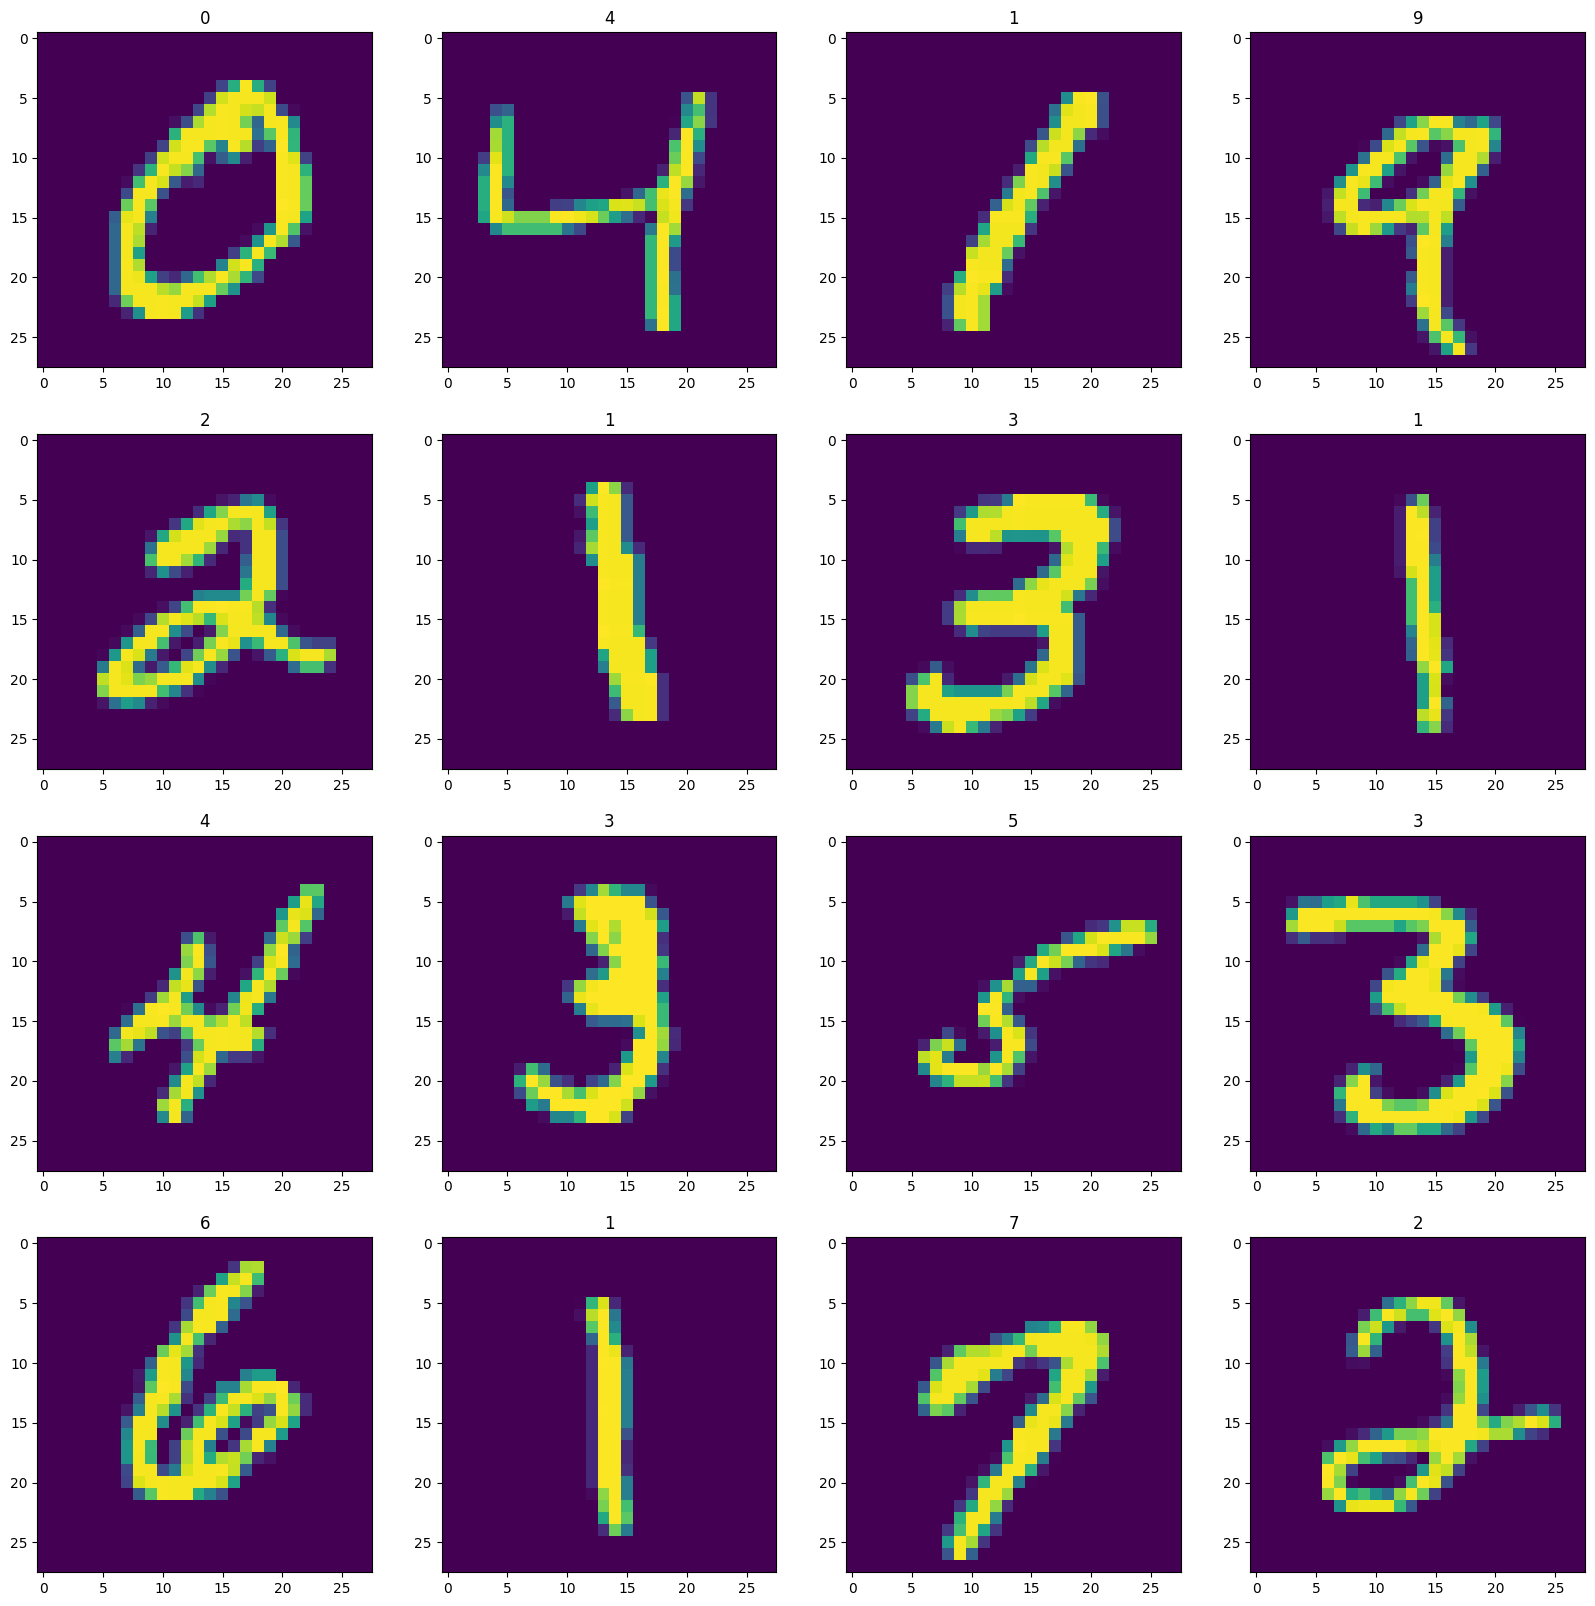

In [5]:

plt.figure(num="Sample Images",figsize=(20,20))
for i in range(1,17):
  plt.subplot(4,4,i)
  img,lbl=next(samples)
  plt.imshow(img)
  plt.title(f"{lbl}", )
plt.show()

#### Task 2

In [6]:
transform = transforms.Compose([
    transforms.RandomAffine(10,scale=(0.8,1.4)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081))
])

The mean nd standard deviation values for MNIST dataset were found to be 0.1307 and 0.3081 resp [Source](https://community.deeplearning.ai/t/mnist-mean-and-std/883455/4)

In [7]:
trainset = datasets.MNIST(root="data", train=True,transform=transform,download=True)
testset = datasets.MNIST(root="data", train=False, download=True)
print(len(trainset))
print(len(testset))

60000
10000


In [8]:
trainloader = DataLoader(trainset, batch_size=64,shuffle=True) #,num_workers=2 if GPU
testloader = DataLoader(testset,batch_size=64) #,num_workers =2 if in GPU

In [9]:
train_samples = iter(trainloader)
img,lbl=next(train_samples)
print(img.shape)
print(lbl.shape)


torch.Size([64, 1, 28, 28])
torch.Size([64])


Task 3

In [13]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.activation import ReLU
class nnet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(

        nn.Conv2d(1,8,3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(8,16,3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Flatten(),
        nn.Linear(16*7*7,10)

    )
  def forward(self,x):
    return self.net(x)


Used 2 convo layers and Relu as activation function and maxpool to shrink size.

In [ ]:
model=nnet()
print(model)
trainr = iter(trainloader)
img,lbl=next(trainr)
output=model(img)
print(output.shape)
